Upload dataset in Colab

In [50]:
from google.colab import files
uploaded = files.upload()



Saving retail_sales_dataset.csv to retail_sales_dataset (1).csv


In [51]:
import pandas as pd

df = pd.read_csv('/content/retail_sales_dataset.csv')

print(df.head())
print(df.info())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   obj

Pairplot (relationship between features)

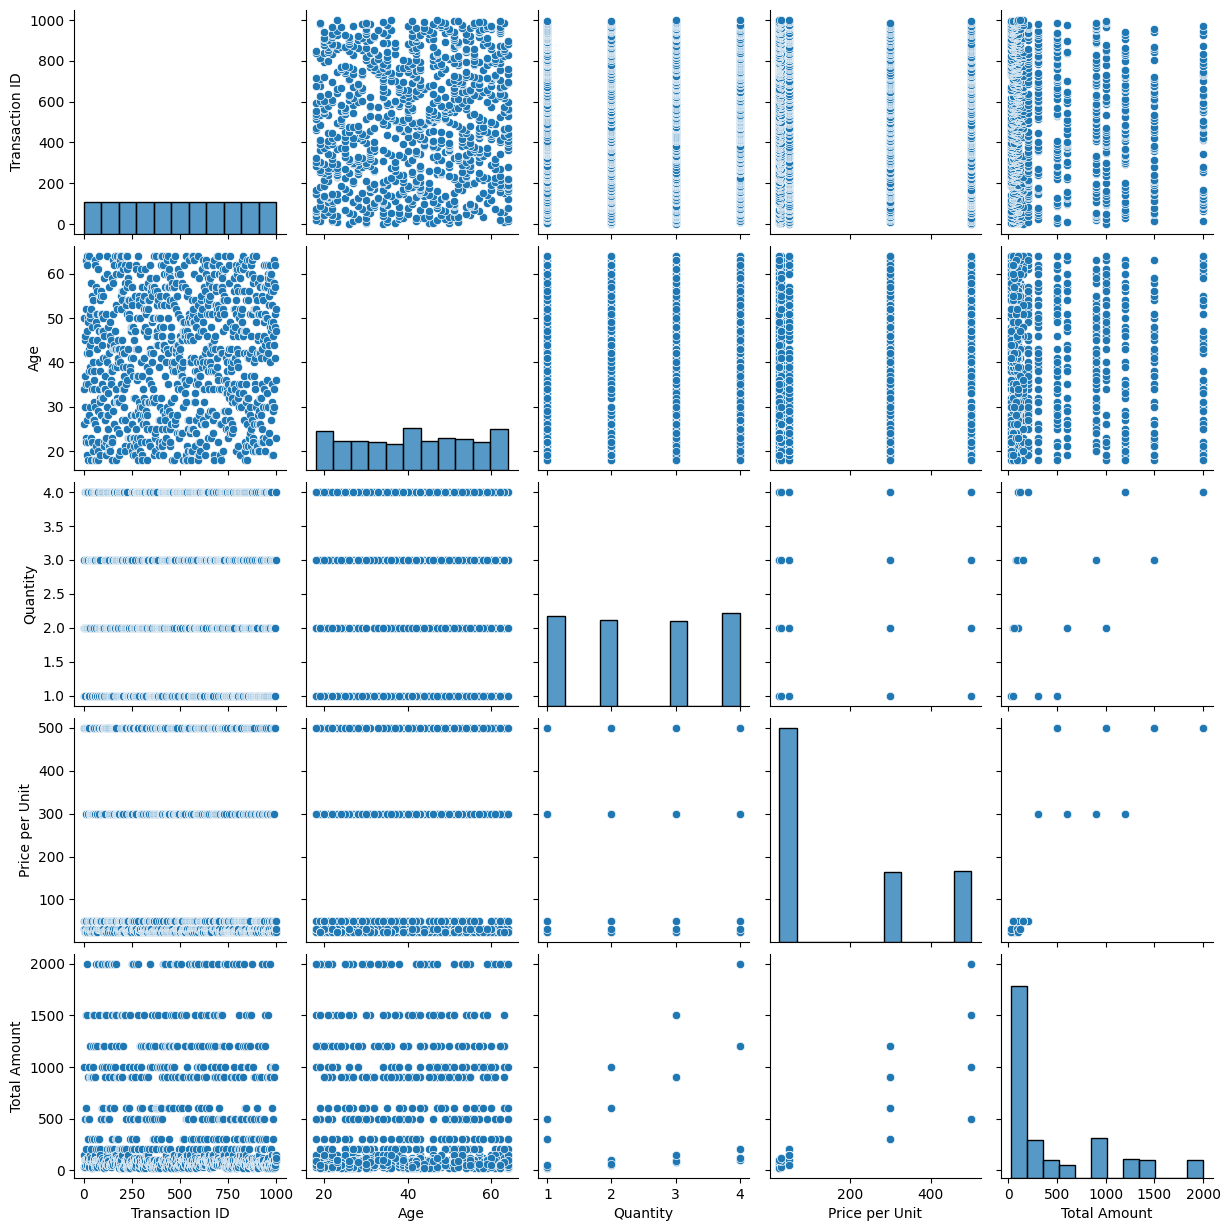

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()


Correlation Heatmap

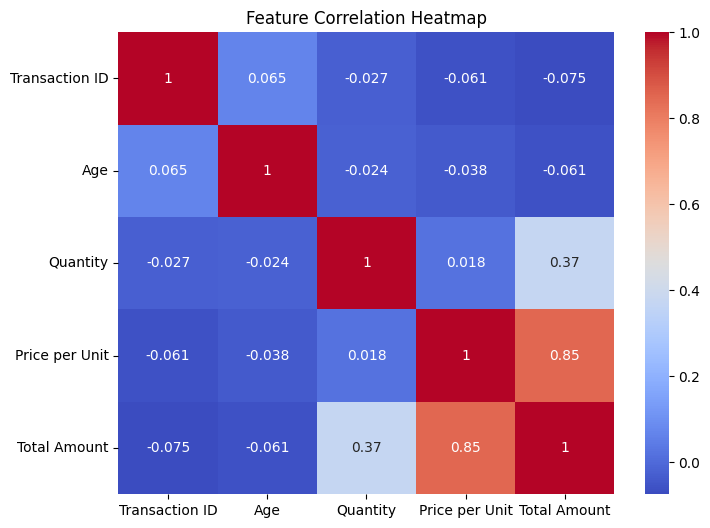

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()



PREPROCESSING

In [54]:
df = df.drop(['CustomerID', 'Date'], axis=1, errors='ignore')


In [55]:
df = df.fillna(df.mean(numeric_only=True))


In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])


select features for clustering

In [57]:
X = df[['Quantity', 'Price per Unit', 'Total Amount']]


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


ELBOW METHOD (WITH VISUAL)

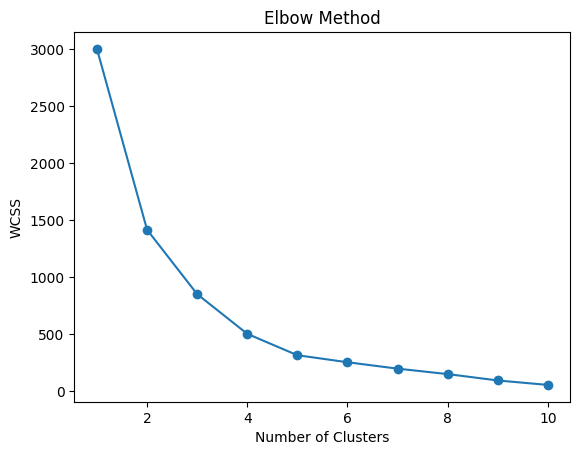

In [59]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


APPLY K-MEANS AND LABEL DATA

In [60]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)
print(df.head())


   Transaction ID  Customer ID  Gender  Age  Product Category  Quantity  \
0               1            0       1   34                 0         3   
1               2            1       0   26                 1         2   
2               3            2       1   50                 2         1   
3               4            3       1   37                 1         1   
4               5            4       1   30                 0         2   

   Price per Unit  Total Amount  Cluster  
0              50           150        2  
1             500          1000        1  
2              30            30        0  
3             500           500        0  
4              50           100        0  


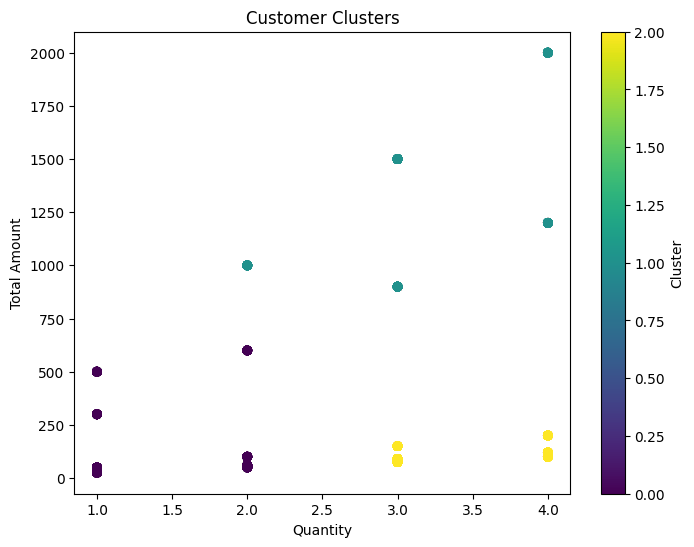

In [61]:
plt.figure(figsize=(8,6))
plt.scatter(df['Quantity'], df['Total Amount'], c=df['Cluster'])
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.title("Customer Clusters")
plt.colorbar(label="Cluster")
plt.show()


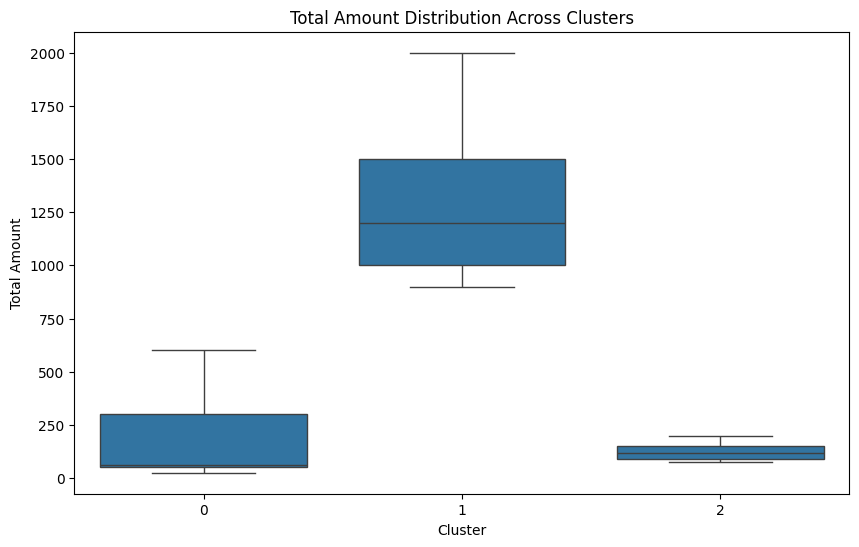

In [62]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Cluster'], y=df['Total Amount'])
plt.title("Total Amount Distribution Across Clusters")
plt.show()


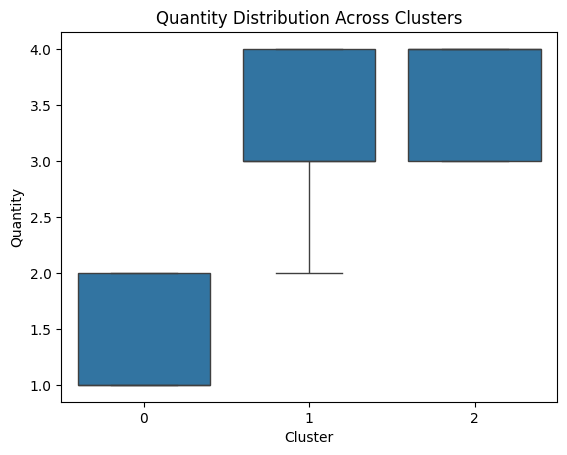

In [63]:
sns.boxplot(x=df['Cluster'], y=df['Quantity'])
plt.title("Quantity Distribution Across Clusters")
plt.show()


In [64]:
cluster_summary = df.groupby('Cluster').mean().round(2)
print(cluster_summary)



         Transaction ID  Customer ID  Gender    Age  Product Category  \
Cluster                                                                 
0                505.88       505.78    0.51  41.90              1.07   
1                468.84       468.74    0.48  40.14              1.02   
2                521.10       517.89    0.46  41.75              0.99   

         Quantity  Price per Unit  Total Amount  
Cluster                                          
0            1.43          136.09        171.94  
1            3.20          412.12       1297.73  
2            3.55           35.50        126.45  


In [65]:
X = df[['Age', 'Gender', 'Quantity']]
y = df['Cluster']


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.64


In [67]:
new_customer = [[30, 1, 7]]   # Age, Gender, Quantity
predicted_cluster = model.predict(new_customer)

print("Predicted Cluster:", predicted_cluster)


Predicted Cluster: [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [68]:
new_customer = [[30, 0, 7]]   # Age, Gender, Quantity
predicted_cluster = model.predict(new_customer)

print("Predicted Cluster:", predicted_cluster)

Predicted Cluster: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [69]:
new_customer = [[20, 1, 2]]   # Age, Gender, Quantity
predicted_cluster = model.predict(new_customer)

print("Predicted Cluster:", predicted_cluster)

Predicted Cluster: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [70]:
new_customer = [[60, 0, 10]]   # Age, Gender, Quantity
predicted_cluster = model.predict(new_customer)

print("Predicted Cluster:", predicted_cluster)

Predicted Cluster: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
